# 04 · Análisis de sensibilidad: tamaño muestral
Genera datasets de tamaño creciente y mide el AUC (CV 5-fold) de cada modelo.
Salida: `figures/fig6_curva_aprendizaje.pdf`

In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

ROOT = Path("..")
sys.path.append(str(ROOT / "src"))
from generar_datos import generar_dataset

plt.rcParams.update({
    "font.family": "serif", "font.size": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "savefig.bbox": "tight",
})

METRICAS = ["PrecisionPase", "VelReaccion", "Efectividad1v1", "VelSprint",
            "DistAltaInt", "AciertoRegate", "Recuperaciones", "TomaDecision"]

def pipe_logit():
    return Pipeline([("sc", StandardScaler()),
                     ("m", LogisticRegression(max_iter=2000))])

def pipe_rf():
    return Pipeline([("sc", StandardScaler()),
                     ("m", RandomForestClassifier(n_estimators=100, random_state=7))])

TAMANOS = [40, 80, 160, 320, 640, 1280]
SEMILLAS = range(5)     # 5 réplicas por tamaño para promediar la suerte

filas = []
for n in TAMANOS:
    for seed in SEMILLAS:
        df = generar_dataset(n, seed=seed)
        X, y = df[METRICAS], df["AltoPotencial"]
        cv = StratifiedKFold(5, shuffle=True, random_state=7)
        for nombre, ctor in [("Reg. logística", pipe_logit),
                             ("Random Forest", pipe_rf)]:
            auc = cross_val_score(ctor(), X, y, cv=cv, scoring="roc_auc").mean()
            filas.append({"n": n, "seed": seed, "modelo": nombre, "auc": auc})
    print(f"n={n} listo")

res = pd.DataFrame(filas)
res.groupby(["modelo", "n"])["auc"].agg(["mean", "std"]).round(3)

n=40 listo
n=80 listo
n=160 listo
n=320 listo
n=640 listo
n=1280 listo


mean    std
modelo         n                 
Random Forest  40    0.742  0.139
               80    0.708  0.071
               160   0.768  0.031
               320   0.789  0.021
               640   0.801  0.016
               1280  0.825  0.004
Reg. logística 40    0.765  0.133
               80    0.822  0.046
               160   0.842  0.022
               320   0.845  0.027
               640   0.848  0.016
               1280  0.859  0.007

In [4]:
df_big = generar_dataset(20000, seed=99)
techo = cross_val_score(pipe_logit(), df_big[METRICAS], df_big["AltoPotencial"],
                        cv=StratifiedKFold(5, shuffle=True, random_state=7),
                        scoring="roc_auc").mean()
print(f"AUC techo (n=20000): {techo:.3f}")

AUC techo (n=20000): 0.854


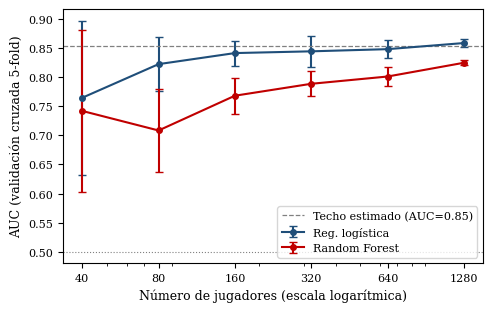

In [5]:
fig, ax = plt.subplots(figsize=(5.0, 3.2))
for nombre, color in [("Reg. logística", "#1f4e79"), ("Random Forest", "#c00000")]:
    sub = res[res.modelo == nombre].groupby("n")["auc"].agg(["mean", "std"])
    ax.errorbar(sub.index, sub["mean"], yerr=sub["std"],
                marker="o", ms=4, capsize=3, color=color, label=nombre)
ax.axhline(techo, color="gray", ls="--", lw=0.9,
           label=f"Techo estimado (AUC={techo:.2f})")
ax.axhline(0.5, color="gray", ls=":", lw=0.8)
ax.set_xscale("log")
ax.set_xticks(TAMANOS)
ax.set_xticklabels(TAMANOS)
ax.set_xlabel("Número de jugadores (escala logarítmica)")
ax.set_ylabel("AUC (validación cruzada 5-fold)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(ROOT / "figures/fig6_curva_aprendizaje.pdf")